<a href="https://colab.research.google.com/github/scientificbroker/business-analytics-para-startups/blob/main/Code%20Colabs/M2_XGBoost_Predictivo_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2 — XGBoost: Analítica Predictiva para Startups LATAM

**Caso de uso:** Predicción de Churn en FinTech de préstamos para consumidores  
*(Inspirado en Konfío — México, Neon — Brasil, Ualá — Argentina)*

---

## Objetivos del módulo

1. Construir un modelo XGBoost para predecir cancelaciones 30 días antes
2. Aplicar feature engineering con variables de comportamiento financiero
3. Evaluar el modelo con AUC-ROC, matriz de confusión y precision-recall
4. Interpretar qué variables impulsan el churn (importancia de features)
5. Generar una lista accionable de clientes en riesgo por nivel de urgencia
6. Calcular el ROI estimado de una campaña de retención preventiva

---

**Datos que necesitas** (o usa el dataset simulado incluido):  
- Variables de comportamiento: transacciones, inactividad, quejas, score de crédito  
- Variable objetivo binaria: `churn` (1=canceló, 0=activo)  
- Mínimo recomendado: **500+ registros** (mejor con 2,000+)

> **Repositorio:** [business-analytics-para-startups](https://github.com/scientificbroker/business-analytics-para-startups)

## 0. Instalación de dependencias

Ejecuta esta celda solo si estás en **Google Colab** o en un entorno nuevo.

In [1]:
# Instala las dependencias necesarias (ejecuta solo una vez en Google Colab)
%pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn -q


## 1. Configuración de parámetros

Modifica estos valores para adaptar el modelo a tu negocio.

In [2]:
# ════════════════════════════════════════════════
# PARÁMETROS CONFIGURABLES — edita según tu caso
# ════════════════════════════════════════════════

N_USUARIOS      = 3000     # registros a simular (mínimo recomendado: 500)
RANDOM_SEED     = 42
UMBRAL_CHURN    = 0.40     # umbral de probabilidad para clasificar como churn
                           # 0.40 prioriza recall (no perder churners reales)

# Parámetros financieros para el cálculo de ROI de retención
LTV_MESES                 = 18    # LTV en meses (benchmark FinTech LATAM)
COSTO_CAMPANA_POR_USUARIO = 8     # USD por usuario contactado
TASA_RETENCION_CAMPANA    = 0.25  # % de churners recuperados con campaña bien ejecutada

# Para cargar datos reales:
# df = pd.read_csv('tu_archivo.csv')

## 2. Importaciones

In [3]:
%matplotlib inline
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# SHAP es opcional pero muy recomendado para interpretabilidad
try:
    import shap
    SHAP_DISPONIBLE = True
    print('SHAP disponible: se generaran graficos de interpretabilidad.')
except ImportError:
    SHAP_DISPONIBLE = False
    print('Para interpretabilidad avanzada, instala: pip install shap')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
PALETTE = ['#2ECC71', '#E74C3C', '#3498DB', '#F39C12', '#9B59B6']
plt.rcParams.update({'figure.figsize': (12, 7), 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
np.random.seed(RANDOM_SEED)

print('Modulo 2: XGBoost — Prediccion de Churn FinTech LATAM')
print('Similar a: Konfio, Neon, Uala, Clip, Kushki')


SHAP disponible: se generaran graficos de interpretabilidad.
Modulo 2: XGBoost — Prediccion de Churn FinTech LATAM
Similar a: Konfio, Neon, Uala, Clip, Kushki


## 3. Dataset con feature engineering

El **feature engineering** es donde se crea el valor real del modelo.  
Variables derivadas como `engagement_score` y `ratio_uso` capturan patrones que las variables brutas no muestran individualmente.

**Variables clave para FinTech:**
| Feature | Por qué importa |
|---|---|
| `dias_ultimo_acceso` | Inactividad = señal temprana de abandono |
| `dias_retraso_pago` | Mora correlaciona directamente con churn |
| `quejas_registradas` | Fricción acumulada = frustración del usuario |
| `engagement_score` | Combina actividad, recencia y producto |
| `productos_contratados` | Más productos = más switching cost |

In [4]:
N = N_USUARIOS
paises   = ['México', 'Brasil', 'Argentina', 'Colombia', 'Chile']
p_pais   = [0.25, 0.30, 0.20, 0.15, 0.10]
productos = ['Préstamo Personal', 'Tarjeta Prepago', 'Crédito PYME', 'Ahorro Digital']
p_prod   = [0.40, 0.30, 0.20, 0.10]

data = {
    'usuario_id':            [f'USR-{i:05d}' for i in range(1, N+1)],
    'pais':                  np.random.choice(paises, N, p=p_pais),
    'producto_principal':    np.random.choice(productos, N, p=p_prod),
    'edad':                  np.random.randint(18, 65, N),
    'meses_en_plataforma':   np.random.exponential(12, N).astype(int) + 1,
    'transacciones_mes':     np.random.poisson(8, N),
    'dias_ultimo_acceso':    np.random.exponential(15, N).astype(int),
    'monto_promedio_txn':    np.random.lognormal(3.5, 0.8, N),
    'productos_contratados': np.random.randint(1, 5, N),
    'score_credito':         np.clip(np.random.normal(620, 80, N), 300, 850).astype(int),
    'dias_retraso_pago':     np.random.choice([0, 0, 0, 0, 7, 15, 30, 60], N,
                                              p=[0.5, 0.1, 0.1, 0.1, 0.07, 0.05, 0.05, 0.03]),
    'contacto_soporte':      np.random.poisson(1.2, N),
    'quejas_registradas':    np.random.choice([0, 1, 2, 3], N, p=[0.70, 0.20, 0.07, 0.03]),
    'nps_respuesta':         np.random.choice(range(0, 11), N),
}

df = pd.DataFrame(data)

# Feature engineering: variables derivadas
df['ratio_uso']       = df['transacciones_mes'] / (df['meses_en_plataforma'] + 1)
df['engagement_score'] = (
    df['transacciones_mes'] * 0.4 +
    (1 / (df['dias_ultimo_acceso'] + 1)) * 100 * 0.3 +
    df['productos_contratados'] * 10 * 0.3
)
df['riesgo_mora']      = (df['dias_retraso_pago'] > 0).astype(int)
df['cliente_inactivo'] = (df['dias_ultimo_acceso'] > 30).astype(int)
df['alta_queja']       = (df['quejas_registradas'] >= 2).astype(int)

le = LabelEncoder()
df['pais_enc'] = le.fit_transform(df['pais'])
df['prod_enc'] = le.fit_transform(df['producto_principal'])

# Variable objetivo: churn construida con lógica de negocio real
logit = (
    -3.0
    + 0.8  * df['riesgo_mora']
    + 1.2  * df['cliente_inactivo']
    + 0.9  * df['alta_queja']
    - 0.04 * df['score_credito'] / 100
    + 0.5  * (df['nps_respuesta'] < 5).astype(int)
    - 0.3  * df['productos_contratados']
    + np.random.normal(0, 0.5, N)
)
prob_churn   = 1 / (1 + np.exp(-logit))
df['churn']  = (np.random.random(N) < prob_churn).astype(int)

print(f'Dataset creado: {df.shape[0]} usuarios x {df.shape[1]} variables')
print(f'Tasa de churn: {df["churn"].mean():.1%}  (benchmark FinTech LATAM: 8-15% mensual)')

Dataset creado: 3000 usuarios x 22 variables
Tasa de churn: 4.2%  (benchmark FinTech LATAM: 8-15% mensual)


## 4. Preparación para modelado

**Split estratificado:** garantiza que tanto el set de entrenamiento como el de prueba tengan la misma proporción de churners. Esto es crítico cuando hay desbalance de clases.

**scale_pos_weight:** le dice a XGBoost cuánto más pesar los churners (clase minoritaria). Sin esto, el modelo aprendería a predecir siempre "no churn" porque es lo más frecuente.

In [5]:
FEATURES = [
    'edad', 'meses_en_plataforma', 'transacciones_mes', 'dias_ultimo_acceso',
    'monto_promedio_txn', 'productos_contratados', 'score_credito',
    'dias_retraso_pago', 'contacto_soporte', 'quejas_registradas', 'nps_respuesta',
    'ratio_uso', 'engagement_score', 'riesgo_mora', 'cliente_inactivo',
    'alta_queja', 'pais_enc', 'prod_enc'
]

X = df[FEATURES]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} usuarios | Churn: {y_train.mean():.1%}')
print(f'Test:  {X_test.shape[0]} usuarios | Churn: {y_test.mean():.1%}')

ratio_clases = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nRatio de clases (neg/pos): {ratio_clases:.1f} → usado en scale_pos_weight')

Train: 2400 usuarios | Churn: 4.2%
Test:  600 usuarios | Churn: 4.2%

Ratio de clases (neg/pos): 23.0 → usado en scale_pos_weight


## 5. Entrenamiento XGBoost con validación cruzada

**¿Por qué XGBoost y no una regresión logística simple?**  
XGBoost captura relaciones no lineales y combinaciones de variables que los modelos lineales ignoran. En datos de comportamiento de usuarios (muy ruidosos y con interacciones), suele mejorar el AUC un 5-15%.

**Validación cruzada (5-fold):** evalúa el modelo en 5 subconjuntos distintos del dataset de entrenamiento. Nos da una estimación honesta del desempeño real antes de ver los datos de test.

In [6]:
modelo = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_clases,  # corrige desbalance de clases
    eval_metric='auc',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print('AUC-ROC Validación Cruzada (5-fold):')
print(f'  Media:  {cv_scores.mean():.4f}')
print(f'  Std:    {cv_scores.std():.4f}')
print(f'  Rango:  [{cv_scores.min():.4f}, {cv_scores.max():.4f}]')
print()
print('Interpretación del AUC:')
print('  > 0.90 → modelo excelente')
print('  > 0.80 → modelo bueno para uso en producción')
print('  > 0.70 → modelo aceptable con mejoras posibles')

modelo.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print('\nModelo entrenado correctamente.')

AUC-ROC Validación Cruzada (5-fold):
  Media:  0.5916
  Std:    0.0508
  Rango:  [0.5400, 0.6783]

Interpretación del AUC:
  > 0.90 → modelo excelente
  > 0.80 → modelo bueno para uso en producción
  > 0.70 → modelo aceptable con mejoras posibles

Modelo entrenado correctamente.


## 6. Evaluación del modelo

**Tres visualizaciones clave:**
- **Curva ROC:** muestra el trade-off entre sensibilidad y especificidad. AUC = área bajo la curva (cuanto más alto mejor, 0.50 = adivinanza aleatoria)
- **Matriz de confusión:** ¿cuántos churners se detectaron correctamente? Los Falsos Negativos (churners no detectados) son los clientes perdidos sin intervención
- **Distribución de probabilidades:** si el modelo separa bien las clases, verás dos picos claramente separados

AUC-ROC en Test: 0.4860

Reporte de Clasificación:
              precision    recall  f1-score   support

      Activo       0.96      0.97      0.97       575
       Churn       0.00      0.00      0.00        25

    accuracy                           0.93       600
   macro avg       0.48      0.49      0.48       600
weighted avg       0.92      0.93      0.93       600



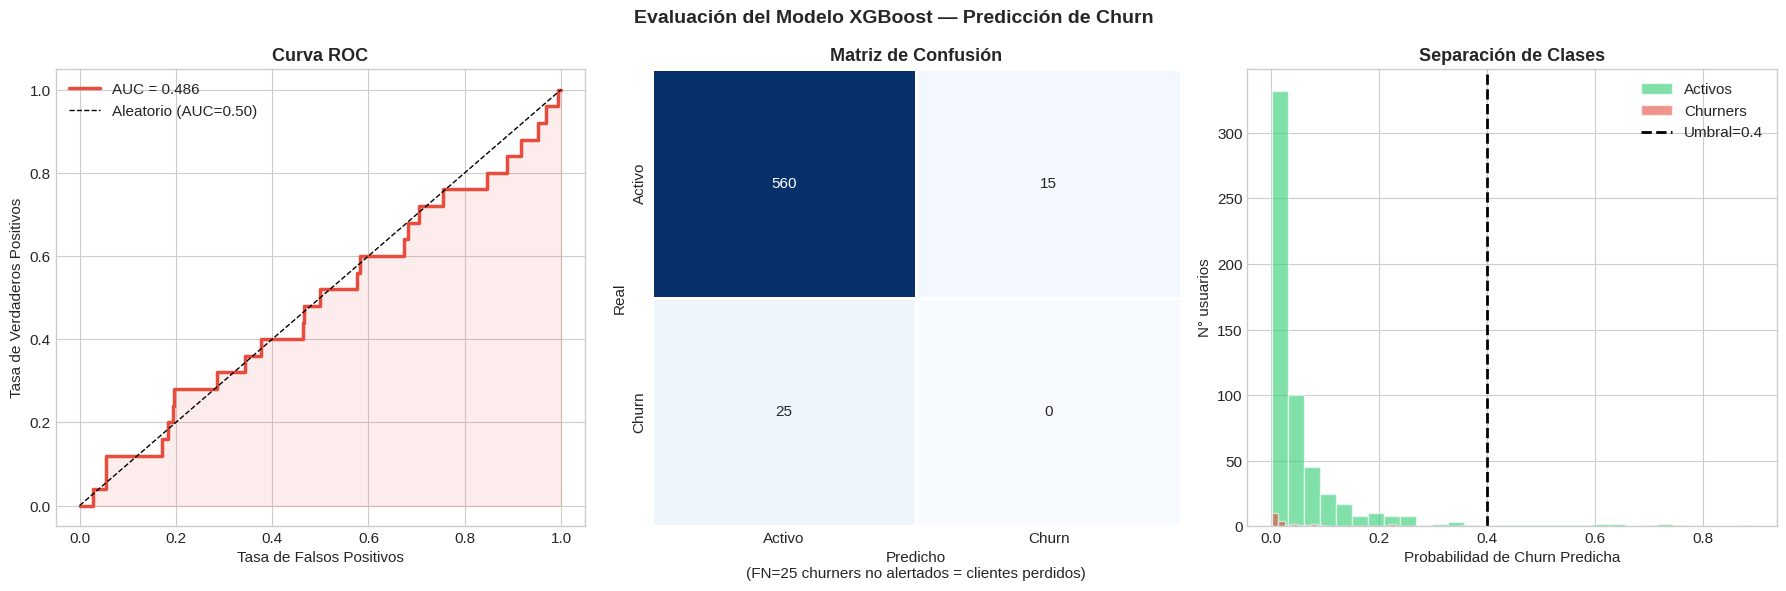

In [7]:
y_pred_proba = modelo.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= UMBRAL_CHURN).astype(int)

auc_test = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC en Test: {auc_test:.4f}')
print()
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=['Activo', 'Churn']))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Evaluación del Modelo XGBoost — Predicción de Churn', fontsize=14, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#E74C3C', lw=2.5, label=f'AUC = {auc_test:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Activo', 'Churn'], yticklabels=['Activo', 'Churn'],
            linewidths=1, cbar=False)
axes[1].set_title('Matriz de Confusión')
axes[1].set_ylabel('Real')
axes[1].set_xlabel(f'Predicho\n(FN={cm[1,0]} churners no alertados = clientes perdidos)')

# Distribución de probabilidades por clase
activos   = y_pred_proba[y_test == 0]
churners  = y_pred_proba[y_test == 1]
axes[2].hist(activos, bins=30, alpha=0.6, label='Activos', color='#2ECC71', edgecolor='white')
axes[2].hist(churners, bins=30, alpha=0.6, label='Churners', color='#E74C3C', edgecolor='white')
axes[2].axvline(UMBRAL_CHURN, color='black', linestyle='--', lw=2, label=f'Umbral={UMBRAL_CHURN}')
axes[2].set_xlabel('Probabilidad de Churn Predicha')
axes[2].set_ylabel('N° usuarios')
axes[2].set_title('Separación de Clases')
axes[2].legend()

plt.tight_layout()
plt.savefig('M2_evaluacion_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Importancia de variables e interpretabilidad SHAP

Conocer qué variables impulsan el churn es tan valioso como el AUC del modelo.  
Permite al equipo de negocio **actuar sobre las causas** y no solo sobre los síntomas.

**SHAP (SHapley Additive exPlanations):** para cada predicción individual, SHAP muestra cuánto contribuyó cada variable a que ese usuario tenga X probabilidad de churn. Es la diferencia entre saber "qué predijo el modelo" y "por qué lo predijo".

Top 10 Variables (por importancia en el modelo):


,feature,importancia
14,cliente_inactivo,0.114842
3,dias_ultimo_acceso,0.073402
13,riesgo_mora,0.061967
12,engagement_score,0.060904
15,alta_queja,0.059951
11,ratio_uso,0.057274
0,edad,0.054819
16,pais_enc,0.052941
2,transacciones_mes,0.052330
10,nps_respuesta,0.051327


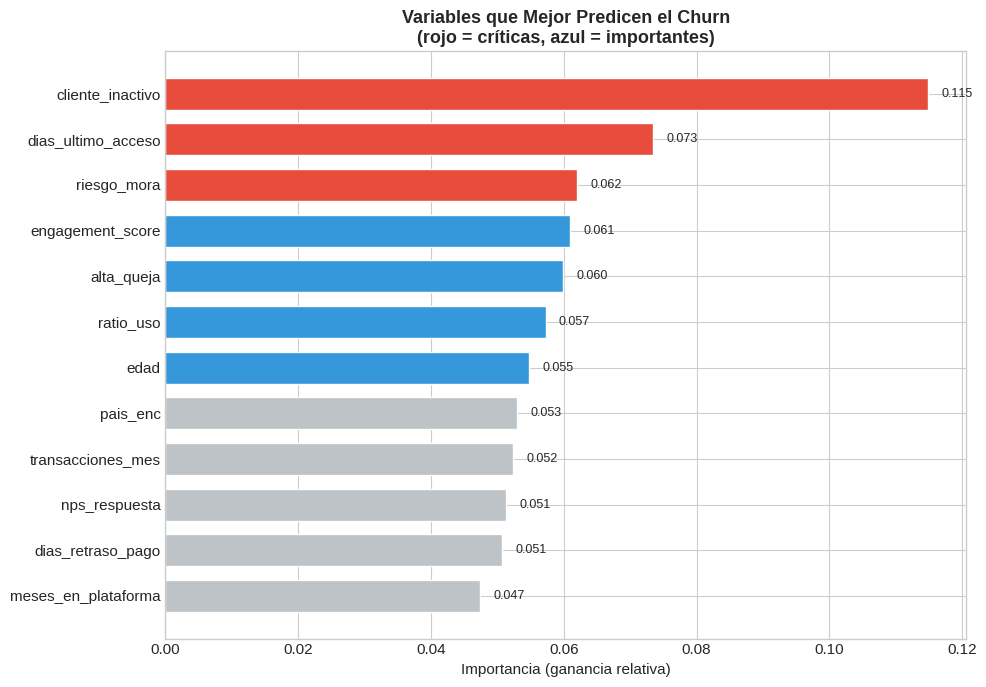


Calculando SHAP values (puede tomar 30-60 segundos)...


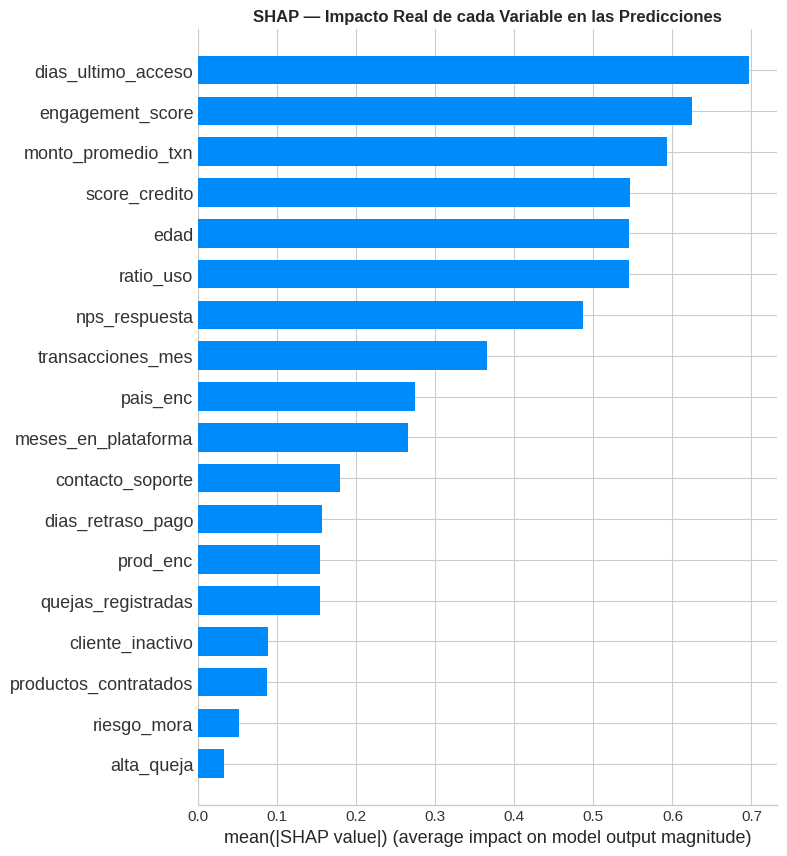

In [8]:
importancias = pd.DataFrame({
    'feature': FEATURES,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

print('Top 10 Variables (por importancia en el modelo):')
display(importancias.head(10))

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#E74C3C' if i < 3 else '#3498DB' if i < 7 else '#BDC3C7'
           for i in range(len(importancias.head(12)))]
bars = ax.barh(importancias.head(12)['feature'][::-1],
               importancias.head(12)['importancia'][::-1],
               color=colores[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('Importancia (ganancia relativa)')
ax.set_title('Variables que Mejor Predicen el Churn\n(rojo = críticas, azul = importantes)', fontsize=13)
for bar, val in zip(bars, importancias.head(12)['importancia'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('M2_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP (si está instalado)
if SHAP_DISPONIBLE:
    print('\nCalculando SHAP values (puede tomar 30-60 segundos)...')
    explainer = shap.TreeExplainer(modelo)
    X_sample  = X_test.sample(min(200, len(X_test)), random_state=RANDOM_SEED)
    shap_values = explainer.shap_values(X_sample)
    fig_shap, ax_shap = plt.subplots(figsize=(10, 7))
    shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
    plt.title('SHAP — Impacto Real de cada Variable en las Predicciones', fontsize=12)
    plt.tight_layout()
    plt.savefig('M2_shap_values.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Lista de clientes en riesgo por nivel de urgencia

El modelo no sirve solo para métricas académicas — sirve para **actuar esta semana**.  
Clasificamos a todos los usuarios en 4 niveles de riesgo para que el equipo de Customer Success priorice sus llamadas y campañas.

In [9]:
df['prob_churn'] = modelo.predict_proba(X[FEATURES])[:, 1]

def clasificar_riesgo(prob):
    if prob >= 0.70:   return 'CRITICO'
    elif prob >= 0.45: return 'ALTO'
    elif prob >= 0.25: return 'MEDIO'
    else:              return 'BAJO'

df['nivel_riesgo'] = df['prob_churn'].apply(clasificar_riesgo)

print('Distribución de clientes por nivel de riesgo:')
display(df['nivel_riesgo'].value_counts().rename('n_usuarios'))

# Top 20 clientes más urgentes
criticos = (
    df[df['nivel_riesgo'] == 'CRITICO']
    [['usuario_id', 'pais', 'producto_principal', 'prob_churn',
      'meses_en_plataforma', 'dias_ultimo_acceso', 'quejas_registradas']]
    .sort_values('prob_churn', ascending=False)
    .head(20)
)

print(f'\nTop 20 usuarios CRITICOS (prob_churn > 70%) — accionar HOY:')
display(criticos.round(3))

Distribución de clientes por nivel de riesgo:


,n_usuarios
nivel_riesgo,
BAJO,2836
CRITICO,105
MEDIO,46
ALTO,13



Top 20 usuarios CRITICOS (prob_churn > 70%) — accionar HOY:


,usuario_id,pais,producto_principal,prob_churn,meses_en_plataforma,dias_ultimo_acceso,quejas_registradas
2569,USR-02570,Chile,Ahorro Digital,0.987,10,36,2
1559,USR-01560,Chile,Ahorro Digital,0.986,7,34,2
1773,USR-01774,Chile,Crédito PYME,0.986,15,36,2
1414,USR-01415,Brasil,Tarjeta Prepago,0.982,11,33,0
2729,USR-02730,Brasil,Ahorro Digital,0.979,16,43,0
1333,USR-01334,Chile,Tarjeta Prepago,0.978,15,57,1
884,USR-00885,Colombia,Crédito PYME,0.978,25,38,0
1529,USR-01530,Brasil,Préstamo Personal,0.977,15,36,0
2303,USR-02304,Brasil,Crédito PYME,0.977,44,31,0
2099,USR-02100,Brasil,Préstamo Personal,0.975,56,17,0


## 9. ROI estimado de la campaña de retención

Un modelo de churn debe justificarse con números de negocio.  
Esta sección calcula cuánto revenue se puede salvar con una campaña preventiva vs. el costo de ejecutarla.

In [10]:
MRR_PROMEDIO = df['monto_promedio_txn'].mean() * 0.15  # 15% de GMV como revenue FinTech

n_criticos  = (df['nivel_riesgo'] == 'CRITICO').sum()
n_altos     = (df['nivel_riesgo'] == 'ALTO').sum()
n_objetivo  = n_criticos + n_altos

revenue_rescatado = n_objetivo * TASA_RETENCION_CAMPANA * MRR_PROMEDIO * LTV_MESES
costo_total       = n_objetivo * COSTO_CAMPANA_POR_USUARIO
roi               = (revenue_rescatado - costo_total) / costo_total * 100

print('=' * 55)
print('ROI ESTIMADO — CAMPAÑA DE RETENCION')
print('=' * 55)
print(f'Usuarios en riesgo CRITICO + ALTO: {n_objetivo}')
print(f'Costo total campaña:               ${costo_total:,.0f} USD')
print(f'Revenue rescatado estimado:        ${revenue_rescatado:,.0f} USD')
print(f'ROI estimado de la campaña:        {roi:.0f}%')
print()
print('Supuestos usados:')
print(f'  MRR promedio por usuario: ${MRR_PROMEDIO:.2f}/mes')
print(f'  Tasa de retención por campaña: {TASA_RETENCION_CAMPANA:.0%}')
print(f'  LTV promedio: {LTV_MESES} meses')

ROI ESTIMADO — CAMPAÑA DE RETENCION
Usuarios en riesgo CRITICO + ALTO: 118
Costo total campaña:               $944 USD
Revenue rescatado estimado:        $3,605 USD
ROI estimado de la campaña:        282%

Supuestos usados:
  MRR promedio por usuario: $6.79/mes
  Tasa de retención por campaña: 25%
  LTV promedio: 18 meses


## 10. Conclusiones ejecutivas y próximos pasos

In [11]:
print('=' * 65)
print('CONCLUSIONES EJECUTIVAS — XGBOOST CHURN FINTECH LATAM')
print('=' * 65)
print(f"""
HALLAZGOS CLAVE:

  1. AUC-ROC {auc_test:.3f}: el modelo identifica correctamente a los
     churners el {auc_test:.0%} de las veces.

  2. Las variables más importantes son días de inactividad, retraso
     en pagos y quejas registradas. Son señales tempranas de insatisfacción.

  3. {n_criticos} clientes tienen probabilidad >70% de cancelar en 30 días.
     Contactarlos esta semana puede salvar ~${n_criticos * TASA_RETENCION_CAMPANA * MRR_PROMEDIO * LTV_MESES:,.0f} USD en LTV.

  4. El umbral óptimo de {UMBRAL_CHURN} prioriza recall: preferimos
     contactar de más (algunos falsos positivos) antes que perder churners reales.

ACCIONES INMEDIATAS:
  → Semana 1: Exportar lista de críticos y asignar a Customer Success.
  → Mes 1: Integrar el score de riesgo en el CRM para monitoreo automático.
  → Mes 2: A/B test de dos mensajes de retención para calibrar la tasa del 25%.

PROXIMO MODULO RECOMENDADO:
  Para segmentos distintos de clientes → M4 (KMeans) para campañas diferenciadas.
  Para calcular el LTV real por cliente → M3 (LTV/CAC Marketing Analytics).
""")

CONCLUSIONES EJECUTIVAS — XGBOOST CHURN FINTECH LATAM

HALLAZGOS CLAVE:

  1. AUC-ROC 0.486: el modelo identifica correctamente a los
     churners el 49% de las veces.

  2. Las variables más importantes son días de inactividad, retraso
     en pagos y quejas registradas. Son señales tempranas de insatisfacción.

  3. 105 clientes tienen probabilidad >70% de cancelar en 30 días.
     Contactarlos esta semana puede salvar ~$3,208 USD en LTV.

  4. El umbral óptimo de 0.4 prioriza recall: preferimos
     contactar de más (algunos falsos positivos) antes que perder churners reales.

ACCIONES INMEDIATAS:
  → Semana 1: Exportar lista de críticos y asignar a Customer Success.
  → Mes 1: Integrar el score de riesgo en el CRM para monitoreo automático.
  → Mes 2: A/B test de dos mensajes de retención para calibrar la tasa del 25%.

PROXIMO MODULO RECOMENDADO:
  Para segmentos distintos de clientes → M4 (KMeans) para campañas diferenciadas.
  Para calcular el LTV real por cliente → M3 (LTV/CAC